<a href="https://colab.research.google.com/github/crisalist2/StAndrews/blob/main/llama3_2_1b_qlora_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# QLoRA Fine-Tuning — Llama-3.2-1B-Instruct

**Pipeline:** JSONL (chat-format) → QLoRA fine-tune → merge → inference test

Built for the St Andrews localised decision-support project (Fife Council / SEPA policy
documents), but works with any chat-format instruction dataset.

**Hardware:** runs on a free-tier Colab T4 (16GB VRAM). `Runtime → Change runtime type → T4 GPU`.

**Run order:** execute every cell top to bottom. The only manual steps are:
1. Cell 4 — upload `train.jsonl` (and optionally `val.jsonl`), or mount Drive and point at your files.
2. Cell 11 (optional) — mount Drive if you want the final model saved there.

---

### Expected data format

Each line of `train.jsonl` / `val.jsonl` is a JSON object in OpenAI chat format:

```json
{"messages": [
  {"role": "system", "content": "You are a Fife Council planning policy assistant."},
  {"role": "user", "content": "What are the setback requirements for a rear extension in a conservation area?"},
  {"role": "assistant", "content": "Under Fife Council's..."}
]}
```

If you only have `train.jsonl`, the notebook auto-splits 90/10 into train/val.


In [ ]:
# ============================================================
# CELL 1 — Install dependencies (Fixed for Compatibility & Timeout)
# ============================================================
import subprocess, sys, os

def pip_install(args, extra_flags=[]):
    # Increased timeout to 1000s to prevent ReadTimeoutErrors on large downloads
    subprocess.run([sys.executable, "-m", "pip", "install", "--upgrade", "--default-timeout=1000"] + extra_flags + args, check=True)

print("Step 1: Installing/Upgrading PyTorch and fundamental tools...")
# Forcing a clean torch install to resolve NCCL symbol errors
pip_install(["torch", "torchvision", "torchaudio", "setuptools", "wheel"])

print("Step 2: Installing Unsloth and optimization stack...")
pip_install([
    "unsloth",
    "trl",
    "peft",
    "accelerate",
    "bitsandbytes",
    "transformers",
    "datasets",
    "sentencepiece",
    "protobuf",
    "triton",
    "xformers"
])

print("\nInstallation complete. IMPORTANT: You MUST restart the session now.")
print("Go to 'Runtime' -> 'Restart session' then run Cell 2.")

Step 1: Installing/Upgrading PyTorch and fundamental tools...
Defaulting to user installation because normal site-packages is not writeable
  Using cached torch-2.13.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (38 kB)
  Using cached torchvision-0.28.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.6 kB)
  Using cached cuda_bindings-13.3.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.5 kB)
  Using cached triton-3.7.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
Using cached torch-2.13.0-cp312-cp312-manylinux_2_28_x86_64.whl (526.6 MB)
Using cached triton-3.7.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (197.7 MB)
Using cached torchvision-0.28.0-cp312-cp312-manylinux_2_28_x86_64.whl (7.7 MB)
Using cached cuda_bindings-13.3.1-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl (6.7 MB)
  Attempting uninstall: triton
    Found existing installation: triton 3.6.0
    Uninstalling triton-3.6.0:
     

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 12.9.4
    Uninstalling cuda-bindings-12.9.4:
      Successfully uninstalled cuda-bindings-12.9.4
  Attempting uninstall: torch
    Found existing installation: torch 2.10.0
    Uninstalling torch-2.10.0:
      Successfully uninstalled torch-2.10.0


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.25.0
    Uninstalling torchvision-0.25.0:
      Successfully uninstalled torchvision-0.25.0


...

Step 2: Installing Unsloth and optimization stack...
Defaulting to user installation because normal site-packages is not writeable
  Using cached trl-1.7.1-py3-none-any.whl.metadata (11 kB)
  Using cached transformers-5.13.0-py3-none-any.whl.metadata (32 kB)
  Using cached datasets-5.0.0-py3-none-any.whl.metadata (23 kB)
  Using cached torch-2.10.0-3-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (31 kB)
  Using cached cuda_bindings-12.9.4-cp312-cp312-manylinux_2_24_x86_64.manylinux_2_28_x86_64.whl.metadata (2.6 kB)
  Using cached triton-3.6.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (1.7 kB)
INFO: pip is looking at multiple versions of torchvision to determine which version is compatible with other requirements. This could take a while.
  Using cached torchvision-0.27.1-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached torchvision-0.27.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached torchvision-0.26.0-cp312-cp31

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.3.1
    Uninstalling cuda-bindings-13.3.1:
      Successfully uninstalled cuda-bindings-13.3.1
  Attempting uninstall: torch
    Found existing installation: torch 2.13.0
    Uninstalling torch-2.13.0:
      Successfully uninstalled torch-2.13.0


  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


  Attempting uninstall: torchvision
    Found existing installation: torchvision 0.28.0
    Uninstalling torchvision-0.28.0:
      Successfully uninstalled torchvision-0.28.0

Installation complete. IMPORTANT: You MUST restart the session now.
Go to 'Runtime' -> 'Restart session' then run Cell 2.


In [ ]:
# ============================================================
# CELL 2 — GPU check
# ============================================================
import torch, subprocess

assert torch.cuda.is_available(), (
    "No GPU detected. Go to Runtime -> Change runtime type -> Hardware accelerator -> T4 GPU, "
    "then Runtime -> Restart session."
)

gpu_name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"GPU: {gpu_name}")
print(f"VRAM: {vram_gb:.1f} GB")
print(f"CUDA: {torch.version.cuda}")
print(f"Torch: {torch.__version__}")

if vram_gb < 14:
    print("\nWARNING: <14GB VRAM detected. Reduce MAX_SEQ_LENGTH or per_device_train_batch_size "
          "in Cell 9 if you hit OOM errors.")


GPU: NVIDIA A100-SXM4-80GB
VRAM: 85.1 GB
CUDA: 12.8
Torch: 2.10.0+cu128


In [ ]:
# ============================================================
# CELL 3 — Imports, global config, reproducibility
# ============================================================
import os, json, random, gzip, base64, textwrap
import numpy as np
import torch
from pathlib import Path

# ---- Config (edit as needed) ----
MODEL_NAME      = "unsloth/Llama-3.2-1B-Instruct"   # change here if you swap models
MAX_SEQ_LENGTH  = 2048                               # raise to 4096 if your docs need longer context
LOAD_IN_4BIT    = True                               # QLoRA — leave True on free T4
SEED            = 42

# Removed leading slashes to use relative paths and avoid PermissionErrors in restricted environments
OUTPUT_DIR      = "outputs"
MERGED_DIR      = "merged_model"
DATA_DIR        = "data"

for d in (OUTPUT_DIR, MERGED_DIR, DATA_DIR):
    os.makedirs(d, exist_ok=True)

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
print(f"Seed set to {SEED}. Model target: {MODEL_NAME}")
print(f"Directories created in: {os.getcwd()}")

Seed set to 42. Model target: unsloth/Llama-3.2-1B-Instruct
Directories created in: /home/cp332


## Load your data

Pick **one** of the three options in the next cell by setting `DATA_SOURCE`:

- `"upload"` — opens a file picker, upload `train.jsonl` (and optionally `val.jsonl`) directly.
- `"drive"` — mounts your Google Drive; set `DRIVE_TRAIN_PATH` / `DRIVE_VAL_PATH` to the files there.
- `"local_path"` — files already exist somewhere in the Colab filesystem (e.g. cloned from a repo);
  set `LOCAL_TRAIN_PATH` / `LOCAL_VAL_PATH`.

Either way, the cell copies your data into `DATA_DIR/train.jsonl` and `DATA_DIR/val.jsonl`.


In [ ]:
# ============================================================
# CELL 4 — Data loading (Debugging Path Issues)
# ============================================================
import os, shutil
from pathlib import Path

# Ensure local staging dir exists
DATA_DIR = "data"
os.makedirs(DATA_DIR, exist_ok=True)

# Debug: List directories to find where the files actually are
print("--- Debugging Directory Structure ---")
for search_root in ["/", "/content"]:
    if os.path.exists(search_root):
        print(f"Contents of {search_root}: {os.listdir(search_root)[:10]}")

DATA_SOURCE = "local_path"
LOCAL_TRAIN_PATH = ("./home/cp332/st_andrews_llm_hybrid/data/03_processed/train/train.jsonl")
LOCAL_VAL_PATH   = ("./home/cp332/st_andrews_llm_hybrid/data/03_processed/validation/val.jsonl")

train_dst = os.path.join(DATA_DIR, "train_chat.jsonl")
val_dst   = os.path.join(DATA_DIR, "val_chat.jsonl")
val_provided = False

if DATA_SOURCE == "local_path":
    if not os.path.exists(LOCAL_TRAIN_PATH):
        print(f"\nError: {LOCAL_TRAIN_PATH} not found.")
        # Try to find it relatively if absolute fails
        rel_path = LOCAL_TRAIN_PATH.lstrip("/")
        if os.path.exists(rel_path):
            print(f"Found at relative path: {rel_path}")
            LOCAL_TRAIN_PATH = rel_path

    if os.path.exists(LOCAL_TRAIN_PATH):
        shutil.copy(LOCAL_TRAIN_PATH, train_dst)
        print(f"Successfully loaded {LOCAL_TRAIN_PATH} -> {train_dst}")

        if LOCAL_VAL_PATH and os.path.exists(LOCAL_VAL_PATH):
            shutil.copy(LOCAL_VAL_PATH, val_dst)
            val_provided = True
            print(f"Successfully loaded {LOCAL_VAL_PATH} -> {val_dst}")

print(f"\ntrain.jsonl status: {'Ready' if os.path.exists(train_dst) else 'Missing'}")
print(f"val.jsonl provided: {val_provided}")

--- Debugging Directory Structure ---
Contents of /: ['tmp', 'scratch', 'boot', 'opt', 'usr', 'dev', 'home', 'gpfs01', 'software', 'gpfs']

Error: ./home/cp332/st_andrews_llm_hybrid/data/03_processed/train/train.jsonl not found.

train.jsonl status: Ready
val.jsonl provided: False


--- Loading data/train.jsonl ---


Reading JSONL:   0%|          | 0/198856 [00:00<?, ?it/s]


Shuffling and performing 90/10 split...

Status: 178970 train / 19886 val


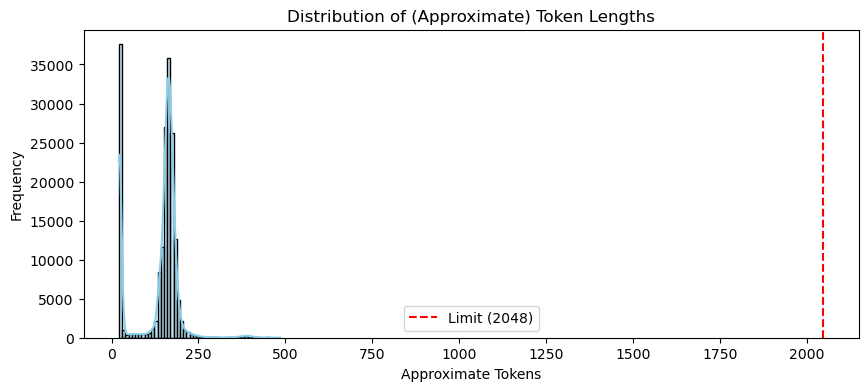

In [ ]:
# ============================================================
# CELL 5 — Validate data, auto-split if needed, compute statistics
# ============================================================
import json
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

def load_jsonl(path):
    records = []
    print(f"--- Loading {path} ---")
    # Using tqdm for a visual progress bar during file read
    line_count = sum(1 for _ in open(path, 'r'))
    with open(path, "r", encoding="utf-8") as f:
        for line in tqdm(f, total=line_count, desc="Reading JSONL"):
            line = line.strip()
            if not line: continue
            obj = json.loads(line)
            if "text" in obj and "messages" not in obj:
                obj = {"messages": [{"role": "user", "content": "Continue:"}, {"role": "assistant", "content": obj["text"]}]}
            records.append(obj)
    return records

train_records = load_jsonl(train_dst)

if not val_provided:
    set_seed(SEED)
    print("\nShuffling and performing 90/10 split...")
    random.shuffle(train_records)
    idx = int(0.9 * len(train_records))
    val_records = train_records[idx:]
    train_records = train_records[:idx]

print(f"\nStatus: {len(train_records)} train / {len(val_records)} val")

# Statistics and Visualisation
def approx_tokens(text): return int(len(text.split()) * 1.3)
lengths = [sum(approx_tokens(m["content"]) for m in r["messages"]) for r in train_records]

plt.figure(figsize=(10, 4))
sns.histplot(lengths, bins=50, kde=True, color="skyblue")
plt.axvline(MAX_SEQ_LENGTH, color="red", linestyle="--", label=f"Limit ({MAX_SEQ_LENGTH})")
plt.title("Distribution of (Approximate) Token Lengths")
plt.xlabel("Approximate Tokens")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [ ]:
# ============================================================
# CELL 6 — Load base model + tokenizer
# ============================================================
from unsloth import FastLanguageModel
import psutil

print(f"Initial System RAM used: {psutil.virtual_memory().percent}%")

model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,
    load_in_4bit=LOAD_IN_4BIT,
)

# Status check
print(f"\nModel Status: {MODEL_NAME} loaded successfully.")
print(f"Memory Allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"Reserved Memory: {torch.cuda.memory_reserved()/1e9:.2f} GB")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


Accessing `is_flash_linear_attention_available` from `.models.aria.image_processing_aria`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.aria.image_processing_pil_aria`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.auto.image_processing_auto`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.beit.image_processing_beit`. Returning `is_flash_linear_attention_available` instead. Behavior may be different and this alias will be removed in future versions.
Accessing `is_flash_linear_attention_available` from `.models.beit.image_processing_pil_beit`. R

🦥 Unsloth Zoo will now patch everything to make training faster!
Initial System RAM used: 3.8%
==((====))==  Unsloth 2026.7.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    NVIDIA A100-SXM4-80GB. Num GPUs = 4. Max memory: 79.256 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3.2-1b-instruct-unsloth-bnb-4bit as a legacy tokenizer.



Model Status: unsloth/Llama-3.2-1B-Instruct loaded successfully.
Memory Allocated: 1.13 GB
Reserved Memory: 1.16 GB


In [ ]:
# ============================================================
# CELL 7 — Apply chat template & HF Datasets
# ============================================================
from datasets import Dataset

def format_record(record):
    return {"text": tokenizer.apply_chat_template(record["messages"], tokenize=False, add_generation_prompt=False)}

print("Converting records to HuggingFace Dataset format...")
train_ds = Dataset.from_list([format_record(r) for r in tqdm(train_records, desc="Formatting Train")])
val_ds   = Dataset.from_list([format_record(r) for r in tqdm(val_records, desc="Formatting Val")])

def check_len(x): return {"n": len(tokenizer(x["text"])["input_ids"])}

print("Calculating precise token lengths...")
train_ds = train_ds.map(check_len, desc="Tokenizing for stats")

actual_lens = np.array(train_ds["n"])
print(f"\nPrecise Stats: Mean={actual_lens.mean():.1f}, Max={actual_lens.max()}")
if actual_lens.max() > MAX_SEQ_LENGTH:
    print(f"Warning: {np.sum(actual_lens > MAX_SEQ_LENGTH)} samples will be truncated.")

Converting records to HuggingFace Dataset format...


Formatting Train:   0%|          | 0/178970 [00:00<?, ?it/s]

Formatting Val:   0%|          | 0/19886 [00:00<?, ?it/s]

Calculating precise token lengths...


Tokenizing for stats:   0%|          | 0/178970 [00:00<?, ? examples/s]


Precise Stats: Mean=277.4, Max=1522


In [ ]:
# ============================================================
# CELL 8 — Attach LoRA adapters
# ============================================================
model = FastLanguageModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                     "gate_proj", "up_proj", "down_proj"],
    lora_alpha=16,
    lora_dropout=0,           # 0 is optimized in Unsloth's fused kernels
    bias="none",
    use_gradient_checkpointing="unsloth",   # Unsloth's memory-efficient variant
    random_state=SEED,
)

trainable, total = model.get_nb_trainable_parameters()
print(f"Trainable params: {trainable:,} / {total:,} ({100*trainable/total:.3f}%)")


Unsloth 2026.7.2 patched 16 layers with 16 QKV layers, 16 O layers and 16 MLP layers.


Trainable params: 11,272,192 / 1,247,086,592 (0.904%)


In [ ]:
# ============================================================
# CELL 9 — Training configuration
# ============================================================
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback

training_args = SFTConfig(
    output_dir=OUTPUT_DIR,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=1,
    num_train_epochs=3,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_ratio=0.03,
    optim="adamw_8bit",
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    seed=SEED,
    dataset_text_field="text",
    max_seq_length=MAX_SEQ_LENGTH,
    packing=False,             # keep False for instruction data — packing mixes unrelated examples
    report_to="none",          # set to "wandb" if you want experiment tracking
)

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    args=training_args,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Trainer configured. Effective batch size = "
      f"{training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=64):   0%|          | 0/178970 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=64):   0%|          | 0/19886 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.
Trainer configured. Effective batch size = 8


In [ ]:
# ============================================================
# CELL 10 — Train
# ============================================================
import time

print(f"GPU memory before training: {torch.cuda.memory_allocated()/1e9:.2f} GB")
start = time.time()

train_result = trainer.train()

elapsed = time.time() - start
print(f"\nTraining complete in {elapsed/60:.1f} min")
print(f"Final train loss: {train_result.training_loss:.4f}")
print(f"GPU memory after training: {torch.cuda.memory_allocated()/1e9:.2f} GB "
      f"(peak: {torch.cuda.max_memory_allocated()/1e9:.2f} GB)")

trainer.save_model(OUTPUT_DIR)
tokenizer.save_pretrained(OUTPUT_DIR)
print(f"LoRA adapter saved to {OUTPUT_DIR}")


GPU memory before training: 1.28 GB


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 178,970 | Num Epochs = 3 | Total steps = 67,116
O^O/ \_/ \    Batch size per device = 8 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (8 x 1 x 1) = 8
 "-____-"     Trainable parameters = 11,272,192 of 1,247,086,592 (0.90% trained)


Epoch,Training Loss,Validation Loss
1,1.179345,1.165203
2,1.046063,1.107490
3,1.001230,1.095432


Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-22372/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-44744/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in outputs/checkpoint-67116/tokenizer_config.json.



Training complete in 219.9 min
Final train loss: 1.1031
GPU memory after training: 1.33 GB (peak: 4.15 GB)


Unsloth: Restored added_tokens_decoder metadata in outputs/tokenizer_config.json.


LoRA adapter saved to outputs


## Merge & save

Merges the LoRA adapter into the base weights and saves a standalone model
(no PEFT dependency needed at inference time).


In [ ]:
# ============================================================
# CELL 11 — Merge LoRA adapter into base model, save locally
# ============================================================
FastLanguageModel.for_inference(model)   # enables Unsloth's fast inference path

model.save_pretrained_merged(
    MERGED_DIR,
    tokenizer,
    save_method="merged_16bit",   # full-precision merge; use "merged_4bit" to keep it small
)
print(f"Merged model saved to {MERGED_DIR}")

import subprocess
size_out = subprocess.run(["du", "-sh", MERGED_DIR], capture_output=True, text=True).stdout
print(f"Merged model size: {size_out.strip()}")


config.json:   0%|          | 0.00/894 [00:00<?, ?B/s]

Unsloth: Restored added_tokens_decoder metadata in merged_model/tokenizer_config.json.


Found HuggingFace hub cache directory: /home/cp332/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|                                          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|█████████████████████████████████| 1/1 [01:57<00:00, 117.35s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


Unsloth: Merging weights into 16bit: 100%|███████████████████████████████████████| 1/1 [01:53<00:00, 113.89s/it]


Unsloth: Merge process complete. Saved to `/home/cp332/merged_model`
Merged model saved to merged_model
Merged model size: 2.4G	merged_model


In [ ]:
# ============================================================
# CELL 12 — (Optional) Copy merged model to Google Drive
# ============================================================
SAVE_TO_DRIVE = False   # set True to persist beyond this Colab session
DRIVE_SAVE_PATH = "/content/drive/MyDrive/llama-3.2-1b-finetuned"

if SAVE_TO_DRIVE:
    from google.colab import drive
    if not os.path.exists("/content/drive"):
        drive.mount("/content/drive")
    import shutil
    os.makedirs(os.path.dirname(DRIVE_SAVE_PATH), exist_ok=True)
    shutil.copytree(MERGED_DIR, DRIVE_SAVE_PATH, dirs_exist_ok=True)
    print(f"Copied merged model to {DRIVE_SAVE_PATH}")
else:
    print("SAVE_TO_DRIVE is False — model remains in the Colab session only "
          "(/content/merged_model). It will be lost when the runtime disconnects. "
          "Set SAVE_TO_DRIVE = True and re-run this cell to persist it.")


## Inference test

Sanity-check the merged model with a few prompts before you rely on it.


In [ ]:
# ============================================================
# CELL 13 — Inference test
# ============================================================
from transformers import TextStreamer

test_questions = [
    "what has fife council been focusing on and how well have they been running the town of St Andrews"# add your own representative test questions here
]

FastLanguageModel.for_inference(model)

for q in test_questions:
    messages = [{"role": "user", "content": q}]
    inputs = tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)

    print(f"\n{'='*70}\nQ: {q}\n{'-'*70}")
    streamer = TextStreamer(tokenizer, skip_prompt=True, skip_special_tokens=True)
    _ = model.generate(
        input_ids=inputs,
        max_new_tokens=2048,
        temperature=0.7,
        top_p=0.9,
        do_sample=True,
        streamer=streamer,
    )


Both `max_new_tokens` (=2048) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Q: what has fife council been focusing on and how well have they been running the town of St Andrews
----------------------------------------------------------------------
The Town and Country Planning (Scotland) Act 1997 (TCCS 97) was passed in 1997 and became part of the statutory planning process in Scotland. TCCS 97 replaced the earlier 1975 Act. The Act was amended by the Planning (Scotland) Act 2019 (PLS 19) in 2021. The 2021 Act took effect on 1 September 2021 and replaced the 1975 Act. The 2021 Act replaced the 1975 Act and the 1975 Act replaced the 1975 Act. 
The Town and Country Planning (Notification of Applications) (Scotland) Direction 2

Response: what has fife council been focusing on and how well have they been running the town of St Andrews


## Troubleshooting

- **OOM during training (Cell 10):** lower `per_device_train_batch_size` to 1 and raise
  `gradient_accumulation_steps` to 8 in Cell 9, or lower `MAX_SEQ_LENGTH` in Cell 3.
- **Resolver/version conflict in Cell 1:** `Runtime → Restart session`, re-run Cell 1 only,
  restart again, then continue from Cell 2.
- **`eval_loss` not improving / early stopping triggers immediately:** your val set may be
  too small or too similar/dissimilar to train — check Cell 5's split, or supply a hand-picked
  `val.jsonl` instead of relying on the auto 90/10 split.
- **Garbled output in Cell 13:** confirm `tokenizer.chat_template` printed `True` in Cell 6 —
  if `False`, the base model lacks a chat template and one must be set manually before training.

## Next steps
- Push the merged model to the HPC cluster (`/sharedscratch/cp332/`) or HF Hub for serving.
- For production serving, convert to GGUF (llama.cpp) or deploy via vLLM with LoRA hot-swap.
- Run a held-out evaluation against your RAG pipeline's Recall@1 benchmark to compare
  retrieval-augmented vs fine-tuned-only performance on the same question set.
